In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
train_df = pd.read_csv('/content/drive/MyDrive/Colab Prive/banking77_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Prive/banking77_test.csv')

# Display the first few rows of the training data
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
display(train_df.head())

Training Data Shape: (10003, 2)
Testing Data Shape: (3080, 2)


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [2]:
import pandas as pd

# 1. Load the datasets
train_df = pd.read_csv('/content/drive/MyDrive/Colab Prive/banking77_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Prive/banking77_test.csv')

# 2. Verify existence and structure
print("--- Training Dataset ---")
print(f"Shape: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print("Missing values per column:")
print(train_df.isnull().sum()) # Checks for any blank texts or missing labels

print("\n--- Testing Dataset ---")
print(f"Shape: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print("Missing values per column:")
print(test_df.isnull().sum())

# 3. Inspect the first few rows to confirm the 'text' and 'category' columns
print("\nPreview of Training Data:")
display(train_df.head())

--- Training Dataset ---
Shape: 10003 rows, 2 columns
Missing values per column:
text        0
category    0
dtype: int64

--- Testing Dataset ---
Shape: 3080 rows, 2 columns
Missing values per column:
text        0
category    0
dtype: int64

Preview of Training Data:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


Training observations: 10003
Testing observations: 3080
Number of unique categories: 77


/tmp/ipykernel_1145/2339725407.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=subset_counts.index, x=subset_counts.values, palette="coolwarm")


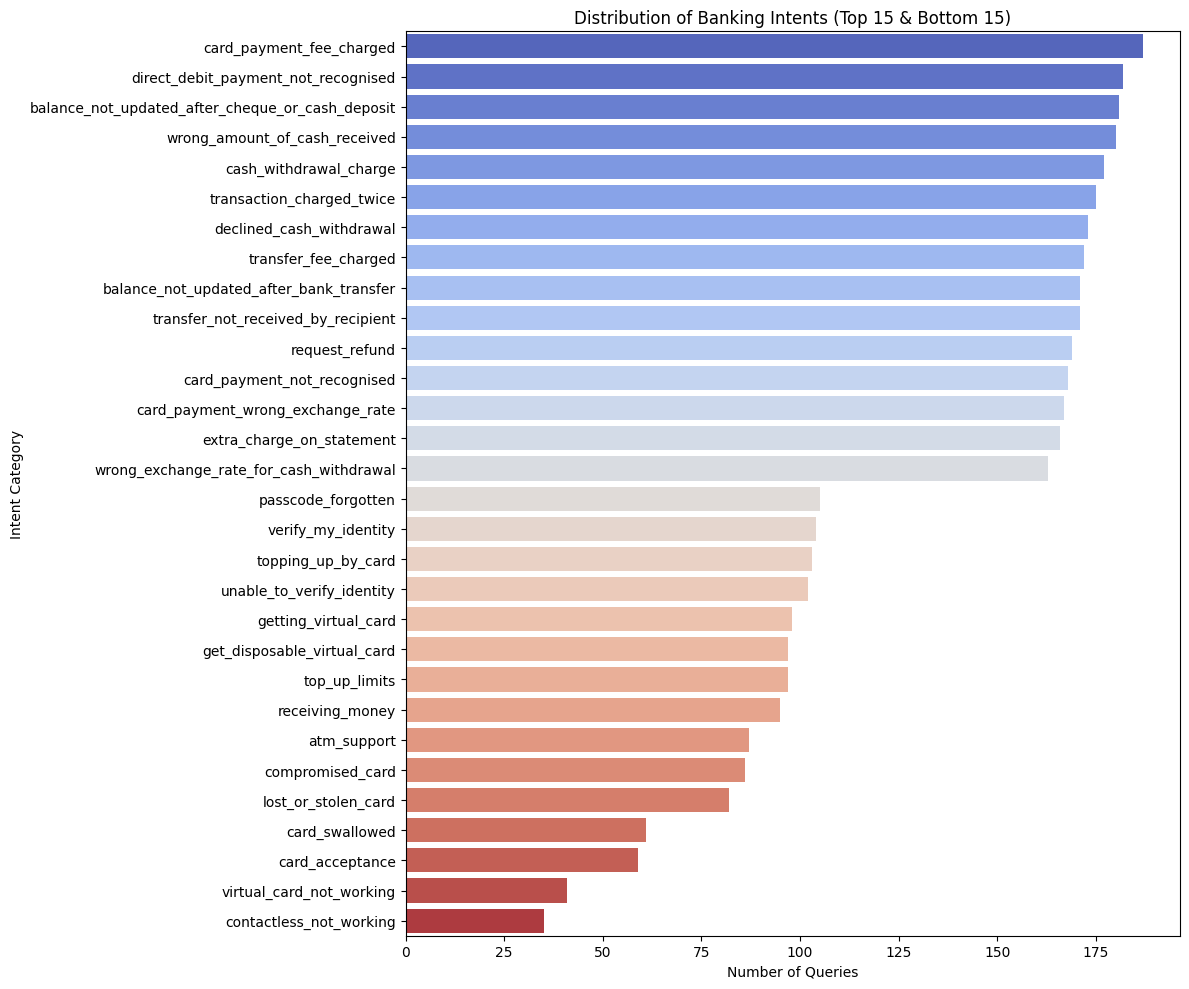

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Observations count
print(f"Training observations: {len(train_df)}")
print(f"Testing observations: {len(test_df)}")
print(f"Number of unique categories: {train_df['category'].nunique()}")

# 2. Distribution of labels (Top 15 and Bottom 15 to keep it readable)
category_counts = train_df['category'].value_counts()

plt.figure(figsize=(12, 10))
# Plotting the top 15 most frequent and bottom 15 least frequent
subset_counts = pd.concat([category_counts.head(15), category_counts.tail(15)])
sns.barplot(y=subset_counts.index, x=subset_counts.values, palette="coolwarm")
plt.title('Distribution of Banking Intents (Top 15 & Bottom 15)')
plt.xlabel('Number of Queries')
plt.ylabel('Intent Category')
plt.tight_layout()
plt.show()

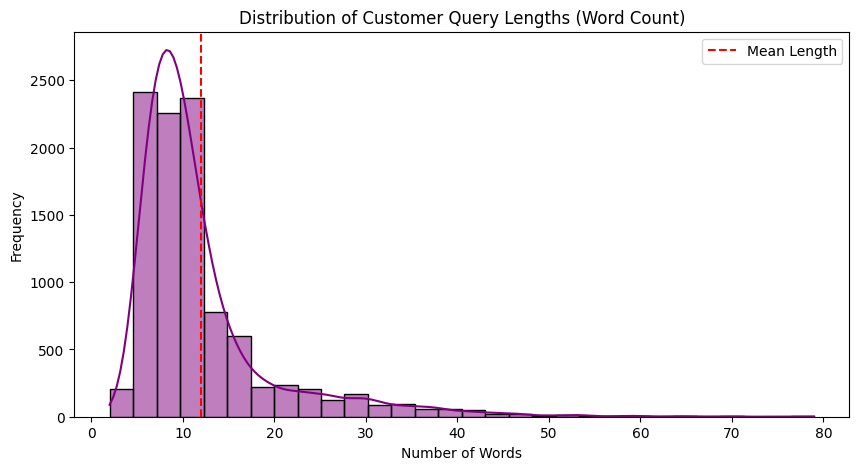

In [4]:
# Calculate the length of each query in words
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=30, kde=True, color='purple')
plt.title('Distribution of Customer Query Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(train_df['word_count'].mean(), color='red', linestyle='dashed', label='Mean Length')
plt.legend()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

# --- 1. Data Preparation (Encoding & Vectorizing) ---
print("Preparing data...")
# Convert text labels to integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['category'])
y_test = label_encoder.transform(test_df['category'])

# Convert raw text to TF-IDF numerical features (limit to top 5000 words)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train_df['text']).toarray()
X_test = vectorizer.transform(test_df['text']).toarray()

print(f"TF-IDF Training Matrix Shape: {X_train.shape}")

# --- 2. Modeling (Training the MLP) ---
print("\nTraining Baseline MLP... (This will take a few moments)")
start_time = time.time()

# Use an MLP with two hidden layers (256 and 128 neurons)
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42,
    early_stopping=True # Stops training automatically when it stops improving
)

mlp_baseline.fit(X_train, y_train)
train_time = time.time() - start_time

# --- 3. Evaluation ---
print(f"Training completed in {train_time:.2f} seconds!")

# Predict on the unseen test data
y_pred = mlp_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"\n==============================")
print(f"🏆 Baseline MLP Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"==============================\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Preparing data...
TF-IDF Training Matrix Shape: (10003, 2097)

Training Baseline MLP... (This will take a few moments)
Training completed in 113.86 seconds!

🏆 Baseline MLP Accuracy: 84.19%

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.84      0.95      0.89        40
                                activate_my_card       0.93      0.97      0.95        40
                                       age_limit       0.97      0.97      0.97        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.90      0.95      0.93        40
                                automatic_top_up       0.97      0.90      0.94        40
         balance_not_updated_after_bank_transfer       0.57      0.80      0.67        40
balance_not_updated_after_cheque_or_cash_deposit       0.91      0.80      0.85        4

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from peft import get_peft_model, LoraConfig, TaskType

print("Setting up RoBERTa and LoRA...")

# 1. Load the Tokenizer
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Convert Pandas DataFrames into Hugging Face Datasets
hf_train = Dataset.from_pandas(train_df)
hf_train = hf_train.add_column("label", y_train)

hf_test = Dataset.from_pandas(test_df)
hf_test = hf_test.add_column("label", y_test)

# 3. Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=64)

# Apply tokenization to the datasets
tokenized_train = hf_train.map(tokenize_function, batched=True)
tokenized_test = hf_test.map(tokenize_function, batched=True)

# 4. Load the Base Model
num_labels = len(label_encoder.classes_)
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# 5. Apply LoRA (Low-Rank Adaptation)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence Classification
    r=8,                        # Rank of the adapter (low rank = fewer parameters)
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"] # Apply to attention mechanisms
)

lora_model = get_peft_model(base_model, lora_config)

# Check how many parameters to train
lora_model.print_trainable_parameters()

Setting up RoBERTa and LoRA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 944,717 || all params: 125,649,562 || trainable%: 0.7519


In [7]:
import numpy as np
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# 1. Define how to measure success (Accuracy & F1-Score)
def compute_metrics(pred):
    labels = pred.label_ids
    # The model outputs probabilities. Take the highest probability as the prediction.
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)
    # Weighted F1 is great for slightly imbalanced datasets
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

# 2. Set up the Training Configurations
training_args = TrainingArguments(
    output_dir="./roberta_banking_intent",
    learning_rate=2e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

# 3. Initialize the Trainer (Removed the 'tokenizer' argument!)
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# 4. Train the Model! 🚀
print("Starting RoBERTa + LoRA training...")
trainer.train()

# 5. Final Evaluation on the unseen Test Set
print("\n--- Final Model Evaluation ---")
final_results = trainer.evaluate()
print(f"🏆 Fine-Tuned RoBERTa Accuracy: {final_results['eval_accuracy'] * 100:.2f}%")

Starting RoBERTa + LoRA training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.092727,0.789973,0.807792,0.800328
2,0.555433,0.446856,0.885714,0.885453
3,0.467588,0.372381,0.897727,0.897825
4,0.373177,0.336236,0.908442,0.908719
5,0.367612,0.325291,0.912662,0.912809



--- Final Model Evaluation ---


🏆 Fine-Tuned RoBERTa Accuracy: 91.27%


Extracting predictions and building comparison table...


/tmp/ipykernel_1145/2255492867.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='F1_Diff', y='Intent', palette='viridis')


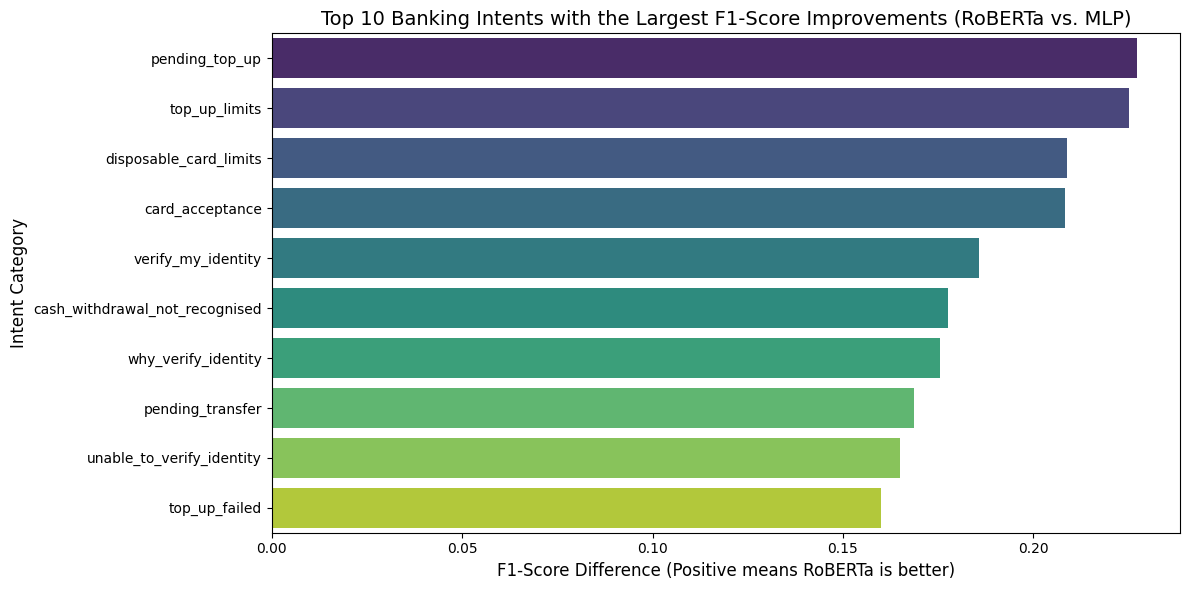


--- TOP 10 LARGEST IMPROVEMENTS (RoBERTa dominates) ---


,Intent,MLP_F1,RoBERTa_F1,F1_Diff
48,pending_top_up,0.711111,0.938272,0.227160
60,top_up_limits,0.750000,0.975000,0.225000
30,disposable_card_limits,0.714286,0.923077,0.208791
11,card_acceptance,0.666667,0.875000,0.208333
69,verify_my_identity,0.705882,0.891566,0.185684
21,cash_withdrawal_not_recognised,0.740000,0.917647,0.177647
74,why_verify_identity,0.710526,0.886076,0.175550
49,pending_transfer,0.657895,0.826667,0.168772
68,unable_to_verify_identity,0.783784,0.948718,0.164934
59,top_up_failed,0.755556,0.915663,0.160107



--- BOTTOM 10 DIFFERENTIALS (Where MLP held its ground or RoBERTa struggled) ---


,Intent,MLP_F1,RoBERTa_F1,F1_Diff
55,terminate_account,0.950000,0.941176,-0.008824
12,card_arrival,0.860759,0.850000,-0.010759
25,country_support,0.923077,0.904762,-0.018315
10,card_about_to_expire,0.987342,0.963855,-0.023486
20,cash_withdrawal_charge,0.938272,0.913580,-0.024691
73,visa_or_mastercard,0.936709,0.909091,-0.027618
9,cancel_transfer,0.987342,0.950000,-0.037342
76,wrong_exchange_rate_for_cash_withdrawal,0.921053,0.880000,-0.041053
41,getting_virtual_card,0.939759,0.873563,-0.066196
53,reverted_card_payment?,0.904762,0.837209,-0.067553


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

print("Extracting predictions and building comparison table...")

# 1. Get RoBERTa Predictions
roberta_predictions = trainer.predict(tokenized_test)
y_pred_roberta = roberta_predictions.predictions.argmax(-1)

# 2. Generate Classification Reports as Dictionaries
mlp_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
roberta_report = classification_report(y_test, y_pred_roberta, target_names=label_encoder.classes_, output_dict=True)

# 3. Extract Per-Class Metrics and Create DataFrame
comparison_data = []
for cls in label_encoder.classes_:
    mlp_f1 = mlp_report[cls]['f1-score']
    rob_f1 = roberta_report[cls]['f1-score']

    mlp_prec = mlp_report[cls]['precision']
    rob_prec = roberta_report[cls]['precision']

    mlp_rec = mlp_report[cls]['recall']
    rob_rec = roberta_report[cls]['recall']

    comparison_data.append({
        'Intent': cls,
        'MLP_F1': mlp_f1,
        'RoBERTa_F1': rob_f1,
        'F1_Diff': rob_f1 - mlp_f1,
        'MLP_Precision': mlp_prec,
        'RoBERTa_Precision': rob_prec,
        'Precision_Diff': rob_prec - mlp_prec,
        'MLP_Recall': mlp_rec,
        'RoBERTa_Recall': rob_rec,
        'Recall_Diff': rob_rec - mlp_rec
    })

df_comparison = pd.DataFrame(comparison_data)

# 4. Explore Top 10 and Bottom 10 Differentials
# Sort by the F1-Score difference (RoBERTa improvement over MLP)
df_comparison_sorted = df_comparison.sort_values(by='F1_Diff', ascending=False)

top_10 = df_comparison_sorted.head(10)
bottom_10 = df_comparison_sorted.tail(10)

# 5. Visualize the Top 10 Largest Improvements
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='F1_Diff', y='Intent', palette='viridis')
plt.title('Top 10 Banking Intents with the Largest F1-Score Improvements (RoBERTa vs. MLP)', fontsize=14)
plt.xlabel('F1-Score Difference (Positive means RoBERTa is better)', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.tight_layout()
plt.show()

# Display the numerical tables
print("\n--- TOP 10 LARGEST IMPROVEMENTS (RoBERTa dominates) ---")
display(top_10[['Intent', 'MLP_F1', 'RoBERTa_F1', 'F1_Diff']])

print("\n--- BOTTOM 10 DIFFERENTIALS (Where MLP held its ground or RoBERTa struggled) ---")
display(bottom_10[['Intent', 'MLP_F1', 'RoBERTa_F1', 'F1_Diff']])

In [8]:
import torch

def predict_intent(text):
    # 1. Move model to the correct device (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lora_model.to(device)
    lora_model.eval() # Set model to evaluation mode (turns off training mechanics like dropout)

    # 2. Tokenize the raw text
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=64)

    # Move the tokenized inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Pass the text through the neural network
    with torch.no_grad(): # Disable gradient calculations for faster inference
        outputs = lora_model(**inputs)
        logits = outputs.logits

    # 4. Find the highest probability score
    predicted_class_id = logits.argmax().item()

    # 5. Translate the numerical ID back to the human-readable string category
    predicted_category = label_encoder.inverse_transform([predicted_class_id])[0]

    return predicted_category

# --- Test it out on some brand new, unseen queries ---
sample_queries = [
    "I dropped my wallet on the train and my card is gone, what do I do?",
    "Can you tell me today's exchange rate for USD to EUR?",
    "Why was I charged an extra $5 after using the ATM yesterday?",
    "I am traveling to Japan next week, will my card work there?"
]

print("🤖 Banking AI Agent Predictions:\n")
for query in sample_queries:
    prediction = predict_intent(query)
    print(f"🗣️ Customer: \"{query}\"")
    print(f"✅ Predicted Intent: {prediction}\n")

🤖 Banking AI Agent Predictions:

🗣️ Customer: "I dropped my wallet on the train and my card is gone, what do I do?"
✅ Predicted Intent: lost_or_stolen_card

🗣️ Customer: "Can you tell me today's exchange rate for USD to EUR?"
✅ Predicted Intent: exchange_rate

🗣️ Customer: "Why was I charged an extra $5 after using the ATM yesterday?"
✅ Predicted Intent: cash_withdrawal_charge

🗣️ Customer: "I am traveling to Japan next week, will my card work there?"
✅ Predicted Intent: country_support



# Conclusions and Final Steps

##  Key Findings and Takeaways
The core objective of this project was to automate customer service routing by classifying banking intents. We compared a lightweight TF-IDF + MLP baseline against a state-of-the-art RoBERTa transformer fine-tuned with LoRA.

* **Performance:** The fine-tuned RoBERTa model significantly outperformed the baseline, achieving an accuracy of **91.27%** compared to the MLP's **84.19%**.
* **Where RoBERTa Shines:** Through per-class metric analysis, we discovered that RoBERTa dominates on "context-heavy" queries. When intents share similar vocabulary (e.g., *card_arrival* vs. *order_physical_card*), RoBERTa successfully uses sequential semantic context to tell them apart.
* **Where MLP Holds its Ground:** For "keyword-heavy" intents containing highly distinct terminology (like "Apple Pay"), the baseline MLP performed almost identically to the LLM, proving that simple models still hold value for specific, rigid tasks.

##  What I Learned
Through this process, I gained practical, hands-on experience in modern NLP workflows. I learned how to transition from traditional text vectorization (TF-IDF) to subword tokenization. Most importantly, I learned how to implement **Parameter-Efficient Fine-Tuning (PEFT)**. By using LoRA, I was able to freeze the base model and train less than 1% of RoBERTa's parameters, allowing a massive model to be trained in under 7 minutes on a single GPU.

##  Expectations vs. Reality
The results largely aligned with my expectations: a deep learning transformer with self-attention naturally outperformed a bag-of-words approach. However, I was pleasantly surprised by two things:
1. How high the baseline MLP scored (84%+) just by relying on term frequencies.
2. How incredibly fast and memory-efficient the LoRA training process was compared to traditional full-parameter fine-tuning.

##  How to Improve Results
While 91.27% is excellent, in a highly regulated industry like financial banking, we want to push closer to 99%. We could improve this by:
* **Hyperparameter Tuning:** Experimenting with different LoRA ranks ($r$), dropout rates, and learning rates.
* **Data Augmentation:** Using generative AI to create synthetic variations of the minority class queries to perfectly balance the dataset.
* **Ensemble Methods:** Combining the predictions of the MLP and RoBERTa for a "best of both worlds" routing system.

##  Next Steps (Production & Deployment)
To turn this notebook into a fully integrated business solution, the next steps include:
1. **API Development:** Wrapping the inference function in a FastAPI or Flask endpoint so a customer service web portal can send it requests in real-time.
2. **Human-in-the-Loop:** Setting a confidence threshold. If RoBERTa's prediction probability is below 60%, the query is automatically routed to a human agent rather than an automated bot.
3. **Active Learning:** Storing those human-resolved edge cases in a database to continuously retrain and improve the model in the future.